In [1]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset
from pygenomeviz.align import Blast, AlignCoord, MMseqs
import matplotlib.pyplot as plt 
import tempfile
import os
from IPython.display import Image, display
import textwrap
import seaborn as sns

import numpy as np
import copy
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio import SeqIO
import pandas as pd
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})
import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch
from matplotlib import cm



In [2]:
def getOverlap(a, b):
    return max(0, min(a[1], b[1]) - max(a[0], b[0]))

In [3]:
ann_dict_simple = {'MG334.mbin.2_00182': 'hypothetical protein (1)',
 'ERR10897979.sbin.2_00762': 'hypothetical protein (2)',
 'ERR10897595.sbin.1_00593': 'hypothetical protein (3)',
 'ERR10897723.sbin.1_00478': 'type II toxin-antitoxin system HicA family toxin',
 'ERR4421622.sbin.2_01193': 'XRE family transcriptional regulator',
 'SRR17635712.mbin.7_01059': 'Na+/H+ antiporter NhaC',
 'ERR10897595.sbin.1_01051': 'hypothetical protein (4)',
 'ERR10897583.sbin.2_00776': 'hypothetical protein (5)',
 'ERR10897696.sbin.1_01201': 'DUF771 domain-containing protein',
 'ERR10897595.sbin.1_00598': 'hypothetical protein (6)',
 'ERR10898139.sbin.1_00313': 'LacI family transcriptional regulator',
 'ERR10897595.sbin.1_00591': 'MarR family transcriptional regulator',
  'ERR10897583.sbin.2_00437': 'type II toxin-antitoxin system HicB family antitoxin',
 }


In [4]:
strain_to_accession = {'2029': 'GCA_000466885.3',
 'CO3MRSI1': 'GCA_003795065.1',
 'AB70': 'GCA_003971565.1',
 'FDAARGOS_743': 'GCA_009730275.1',
 'DC21.1': 'GCA_009769205.1',
 'C25': 'GCA_009933525.1',
 'B4': 'GCA_013456995.1',
 '1D': 'GCA_013487905.1',
 'PRL2021': 'GCA_016767795.1',
 'PMC201': 'GCA_018885325.1',
 'ATCC_33820': 'GCA_018987235.1',
 'Lc1700': 'GCA_020042005.1',
 'Lc1226': 'GCA_020042125.1',
 'Lc116': 'GCA_020042225.1',
 'KT-11': 'GCA_020887095.1',
 'lc83': 'GCA_021278925.1',
 'lc31': 'GCA_021278945.1',
 'M247': 'GCA_026740115.1',
 'Lcr-MH175': 'GCA_027271175.1',
 'VSI04': 'GCA_029011155.1',
 'VSI24': 'GCA_029011475.1',
 'VSI21': 'GCA_029011495.1',
 'VSI17': 'GCA_029011595.1',
 'VSI08': 'GCA_029011765.1',
 'BC1': 'GCA_040109495.1',
 'BC3': 'GCA_041344855.1'}

accession_to_strain = {v:k for k,v in strain_to_accession.items()}

### Download GBFF files

In [7]:
# !rm -r genomes_for_pyGenomeViz
!mkdir genomes_for_pyGenomeViz

for strain, acc in strain_to_accession.items():

    !datasets download genome accession {acc} --include gbff
    !unzip ncbi_dataset.zip
    !mv ncbi_dataset/data/{acc}/genomic.gbff ncbi_dataset/data/{acc}/{strain}.gbff
    !mv ncbi_dataset/data/{acc}/{strain}.gbff genomes_for_pyGenomeViz/
    !rm -r ncbi_dataset/
    !rm ncbi_dataset.zip README.md md5sum.txt



mkdir: genomes_for_pyGenomeViz: File exists
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.56kB 20.6MB/s
Downloading: ncbi_dataset.zip    2.65kB 30.7kB/s
Downloading: ncbi_dataset.zip    2.65kB 30.7kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    3.67kB 34.9kB/s
Downloading: ncbi_dataset.zip    65.5kB 340kB/s
Downloading: ncbi_dataset.

In [5]:
gbk_files = !ls  genomes_for_pyGenomeViz/*gbff
to_keep = [f'genomes_for_pyGenomeViz/{i}.gbff' for i in strain_to_accession.keys()]
gbk_files = [i for i in gbk_files if i in to_keep]
gbk_list = list(map(Genbank, gbk_files))

In [6]:
len(gbk_list)

26

In [7]:
longest_seq_per_strain = {}
to_skip = []
for gbk in gbk_list:

    longest_seq_name = None
    longest_seq_len = 0

    for seqid, features in gbk.get_seqid2features("CDS").items():
        seq_len = gbk.get_seqid2size()[seqid]
        if seq_len > longest_seq_len:
            longest_seq_len = seq_len
            longest_seq_name = seqid

    #these don't have feature annotations in the GBFF files, will exclude
    if not longest_seq_name:
        to_skip += [gbk.name]
        continue


    longest_seq_per_strain[gbk.name] = longest_seq_name


In [8]:
gbk_list = list(map(Genbank, gbk_files))
gv = GenomeViz(track_align_type="center", fig_track_height=0.5)
gv.set_scale_bar()
to_align = []
total_seq_lens = {}

for gbk in gbk_list:

    if gbk.name not in longest_seq_per_strain:
        continue
    to_align += [gbk]
    seqid = longest_seq_per_strain[gbk.name]
    seq_dict = gbk.get_seqid2features("CDS")
    features = seq_dict[seqid]
    seq_len = gbk.get_seqid2size()[seqid]

    total_seq_lens[gbk.name] = gbk.genome_length

### Run BLAST

In [9]:
!mkdir  BLAST_NCBI_to_C75

mkdir: BLAST_NCBI_to_C75: File exists


In [15]:
base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'

In [16]:
cluster_info = pd.read_csv(f'{base_dir}/VMGC/VMGC_db/pangenomes/988598/clusters_99_info.tsv', sep='\t')
c75_list = cluster_info['centroid_75'].tolist()

to_write_nuc = ''
to_write_aa = ''
for r in SeqIO.parse(f'{base_dir}/VMGC/VMGC_db/pangenomes/988598/centroids_95.ffn', 'fasta'):
    
    if r.id in c75_list:

        to_write_nuc += f'>{r.id}\n{r.seq}\n'

with open('BLAST_NCBI_to_C75/l_crispatus_C75.fna', 'w') as f:
    f.write(to_write_nuc)




In [18]:
genome_dir = f'{base_dir}/cervical_dysplasia/microSLAM/NCBI_isolates/NCBI_l_crispatus_genomes/ncbi_dataset/data/'

!cat {genome_dir}/*/GCA*fna > BLAST_NCBI_to_C75/lc_genomes_combined.fna
!cat {genome_dir}*/cds_from_genomic.fna > BLAST_NCBI_to_C75/lc_CDS_combined.fna

### BLAST NCBI isolate CDS sequences to C75 pangenomes

In [19]:

!makeblastdb -in BLAST_NCBI_to_C75/l_crispatus_C75.fna -dbtype nucl -out BLAST_NCBI_to_C75/lc_C75_nuc_db
!blastn -task blastn -query BLAST_NCBI_to_C75/lc_CDS_combined.fna \
        -db BLAST_NCBI_to_C75/lc_C75_nuc_db \
        -out BLAST_NCBI_to_C75/l_crispatus_CDS_to_C75.out \
        -outfmt "6 qseqid sseqid pident length qlen qstart qend slen sstart send evalue bitscore" \
        -perc_identity 75



Building a new DB, current time: 09/10/2025 13:15:16
New DB name:   /Users/cdubin/VMGC_cervical_dysplasia_paper/code/cervical_dysplasia/microSLAM/NCBI_isolates/BLAST_NCBI_to_C75/lc_C75_nuc_db
New DB title:  BLAST_NCBI_to_C75/l_crispatus_C75.fna
Sequence type: Nucleotide
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 8675 sequences in 0.119845 seconds.




### Load BLAST results

In [20]:
hit_genes = list(ann_dict_simple.keys())

In [21]:
cols = 'query_acc subject_acc pident length qlen qstart qend slen sstart send evalue bitscore'.split(' ')
cols = [i.replace('. ', '.').replace(' ', '_') for i in cols]


blast_results = pd.read_csv('BLAST_NCBI_to_C75/l_crispatus_CDS_to_C75.out', sep='\t', header=None)
blast_results.columns=cols
blast_results = blast_results[(blast_results['pident'] >= 75)]

blast_results['query_cov'] = blast_results['length'] / blast_results['qlen']
blast_results['subject_cov'] = blast_results['length'] / blast_results['slen']
blast_results = blast_results[(blast_results['query_cov'] >= 0.75)]
blast_results = blast_results[(blast_results['subject_cov'] >= 0.75)]



blast_results['contig_name'] = blast_results['query_acc'].str.split('|', expand=True)[1].str.split('_cds', expand=True)[0]
blast_results = blast_results.sort_values('bitscore', ascending=False).drop_duplicates(['contig_name', 'query_acc'])
blast_results = blast_results[blast_results['subject_acc'].isin(hit_genes)]

protein_to_locus_tag = {}

for g in blast_results['query_acc'].tolist():

    cmd = f'grep "{g}" BLAST_NCBI_to_C75/lc_CDS_combined.fna'
    header = !{cmd}
    locus_tag = header[0].split('locus_tag=')[1].split(']')[0]
    protein_to_locus_tag[g] = locus_tag

blast_results['locus_tag'] = blast_results['query_acc'].map(protein_to_locus_tag)
hit_proteins = blast_results['locus_tag'].tolist()
blast_results['annotation'] = blast_results['subject_acc'].map(ann_dict_simple)

blast_results


,query_acc,subject_acc,pident,length,qlen,qstart,qend,slen,sstart,send,evalue,bitscore,query_cov,subject_cov,contig_name,locus_tag,annotation
2190917,lcl|CP157745.1_cds_XBP97485.1_1732,MG334.mbin.2_00182,94.998,2159,2148,1,2147,2160,1,2159,0.000000e+00,3414.0,1.005121,0.999537,CP157745.1,AAFS18_09035,hypothetical protein (1)
826813,lcl|CP076522.1_cds_QWS36480.1_283,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP076522.1,KO564_01425,hypothetical protein (1)
207252,lcl|CP026503.1_cds_AZR16373.1_2034,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP026503.1,C3K22_10605,hypothetical protein (1)
401189,lcl|CP039266.1_cds_QGY95459.1_1621,MG334.mbin.2_00182,86.985,2159,2148,1,2147,2160,1,2159,0.000000e+00,2625.0,1.005121,0.999537,CP039266.1,E6A57_08505,hypothetical protein (1)
694271,lcl|CP047415.1_cds_QLL74708.1_1986,MG334.mbin.2_00182,86.118,2161,2148,1,2148,2160,1,2160,0.000000e+00,2535.0,1.006052,1.000463,CP047415.1,GTO85_10375,hypothetical protein (1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162090,lcl|CP026503.1_cds_AZR15460.1_1037,ERR10897583.sbin.2_00776,88.492,252,252,1,252,252,1,252,4.510000e-89,324.0,1.000000,1.000000,CP026503.1,C3K22_05495,hypothetical protein (5)
1306351,lcl|CP083393.1_cds_UAY50308.1_1043,ERR10897583.sbin.2_00776,88.095,252,252,1,252,252,1,252,5.490000e-88,320.0,1.000000,1.000000,CP083393.1,LAE50_05525,hypothetical protein (5)
652224,lcl|CP047415.1_cds_QLL73881.1_1058,ERR10897583.sbin.2_00776,86.905,252,252,1,252,252,1,252,1.210000e-83,306.0,1.000000,1.000000,CP047415.1,GTO85_05635,hypothetical protein (5)
1559743,lcl|CP114552.1_cds_WAZ53461.1_1943,ERR10897583.sbin.2_00776,84.921,252,252,1,252,252,1,252,3.960000e-77,284.0,1.000000,1.000000,CP114552.1,O0957_10135,hypothetical protein (5)


In [22]:
[i for i in hit_genes if i not in blast_results['subject_acc'].tolist()]

[]

### Map contig names to strains

In [23]:
genome_files = !ls {genome_dir}/*/GCA*fna
lc_genome_list = !grep '>' BLAST_NCBI_to_C75/lc_genomes_combined.fna

contig_to_strain = {}

for header in lc_genome_list:
    contig_name = header.split(' ')[0].replace('>','')
    
    if 'plasmid' in header:
        strain_name = header.split('Lactobacillus crispatus ')[1].split(' plasmid')[0].split(' DNA')[0].replace('strain ','').replace('isolate ','')
        strain_name = strain_name + '_plasmid'
    else:
        strain_name = header.split('Lactobacillus crispatus ')[1].split(' chromosome')[0].split(' DNA')[0].replace('strain ','').replace('isolate ','')
    contig_to_strain[contig_name] = strain_name

blast_results['strain'] = blast_results['contig_name'].map(contig_to_strain)
blast_results['strain'] = blast_results['strain'].str.replace(' ', '_')
blast_results

,query_acc,subject_acc,pident,length,qlen,qstart,qend,slen,sstart,send,evalue,bitscore,query_cov,subject_cov,contig_name,locus_tag,annotation,strain
2190917,lcl|CP157745.1_cds_XBP97485.1_1732,MG334.mbin.2_00182,94.998,2159,2148,1,2147,2160,1,2159,0.000000e+00,3414.0,1.005121,0.999537,CP157745.1,AAFS18_09035,hypothetical protein (1),BC1
826813,lcl|CP076522.1_cds_QWS36480.1_283,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP076522.1,KO564_01425,hypothetical protein (1),PMC201
207252,lcl|CP026503.1_cds_AZR16373.1_2034,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP026503.1,C3K22_10605,hypothetical protein (1),AB70
401189,lcl|CP039266.1_cds_QGY95459.1_1621,MG334.mbin.2_00182,86.985,2159,2148,1,2147,2160,1,2159,0.000000e+00,2625.0,1.005121,0.999537,CP039266.1,E6A57_08505,hypothetical protein (1),DC21.1
694271,lcl|CP047415.1_cds_QLL74708.1_1986,MG334.mbin.2_00182,86.118,2161,2148,1,2148,2160,1,2160,0.000000e+00,2535.0,1.006052,1.000463,CP047415.1,GTO85_10375,hypothetical protein (1),1D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162090,lcl|CP026503.1_cds_AZR15460.1_1037,ERR10897583.sbin.2_00776,88.492,252,252,1,252,252,1,252,4.510000e-89,324.0,1.000000,1.000000,CP026503.1,C3K22_05495,hypothetical protein (5),AB70
1306351,lcl|CP083393.1_cds_UAY50308.1_1043,ERR10897583.sbin.2_00776,88.095,252,252,1,252,252,1,252,5.490000e-88,320.0,1.000000,1.000000,CP083393.1,LAE50_05525,hypothetical protein (5),Lc116
652224,lcl|CP047415.1_cds_QLL73881.1_1058,ERR10897583.sbin.2_00776,86.905,252,252,1,252,252,1,252,1.210000e-83,306.0,1.000000,1.000000,CP047415.1,GTO85_05635,hypothetical protein (5),1D
1559743,lcl|CP114552.1_cds_WAZ53461.1_1943,ERR10897583.sbin.2_00776,84.921,252,252,1,252,252,1,252,3.960000e-77,284.0,1.000000,1.000000,CP114552.1,O0957_10135,hypothetical protein (5),Lcr-MH175


In [24]:
gene_pres_abs = blast_results.drop_duplicates(['subject_acc', 'strain']).pivot(index='subject_acc', columns='strain', values = 'length')
gene_pres_abs = (gene_pres_abs > 0).astype(int)
for gbk in gbk_list:
    if gbk.name in to_skip:
        continue

    if gbk.name in gene_pres_abs.columns:
        continue

    gene_pres_abs[gbk.name] = [0]*gene_pres_abs.shape[0]

### Plot presence/absence heat map

In [25]:
strain_origins = {
'1D':'horse feces, USA',
'2029':'human vagina, Russia',
'AB70':'human vagina, Korea',
'BC1':'human vagina, Italy',
'BC3':'human vagina, Italy',
'KT-11':'human feces, China',
'Lc116':'human urine, USA',
'Lc1226':'human urine, USA',
'Lcr-MH175':'human vagina, China',
'PRL2021':'human vagina, Italy',
'VSI08':'human vagina, USA',
'VSI21':'human vagina, USA',
'VSI24':'human vagina, USA',
'lc83':'human vagina, China',
'CO3MRSI1':'human vagina, USA',
'DC21.1':'chicken gut, UK',
'C25':'chicken gut, USA',
'B4':'human feces, China',
'PMC201':'human vagina, Korea',
'ATCC_33820':'human oral cavity, China',
'Lc1700':'human urine, USA',
'lc31':'human vagina, China',
'VSI04':'human vagina, USA',
'VSI17':'human vagina, USA',
'FDAARGOS_743':'human vagina, USA',
'M247':'human feces, Italy',
}

strain_origins = pd.DataFrame.from_dict(strain_origins, orient='index')
strain_origins[['source','country']] = strain_origins[0].str.split(', ', expand=True)

lut = {
      'human vagina': 'midnightblue',
 'human urine': 'blue',
   'human feces': 'lightskyblue',
 'human oral cavity': 'lightcyan',

 'chicken gut': 'lime',
 'horse feces': 'green',

}

source_row_colors = strain_origins['source'].map(lut)

col_order = [
    
     'SRR17635712.mbin.7_01059', 
           'ERR10897595.sbin.1_00591',

    'ERR10897696.sbin.1_01201',
    'ERR10897595.sbin.1_00598',
    'ERR10897595.sbin.1_00593', 
'ERR4421622.sbin.2_01193',
'ERR10897979.sbin.2_00762', 
'ERR10897595.sbin.1_01051', 
'ERR10897583.sbin.2_00776', 
'ERR10897723.sbin.1_00478', 
 'ERR10897583.sbin.2_00437',
    'MG334.mbin.2_00182', 
  'ERR10898139.sbin.1_00313',
]

strain_order = [
    
      'VSI04',
  'VSI24',
 'BC3',
'FDAARGOS_743',
    'PMC201',
    'BC1',
     'VSI08',
  'VSI17',
 '2029',
  'Lcr-MH175',
 'VSI21',
 'AB70',
  'PRL2021',
 'Lc116',
  'Lc1700',
  'Lc1226',
 'M247',
  'B4',
'ATCC_33820',
 'DC21.1',
 'C25',
  '1D',
]

 

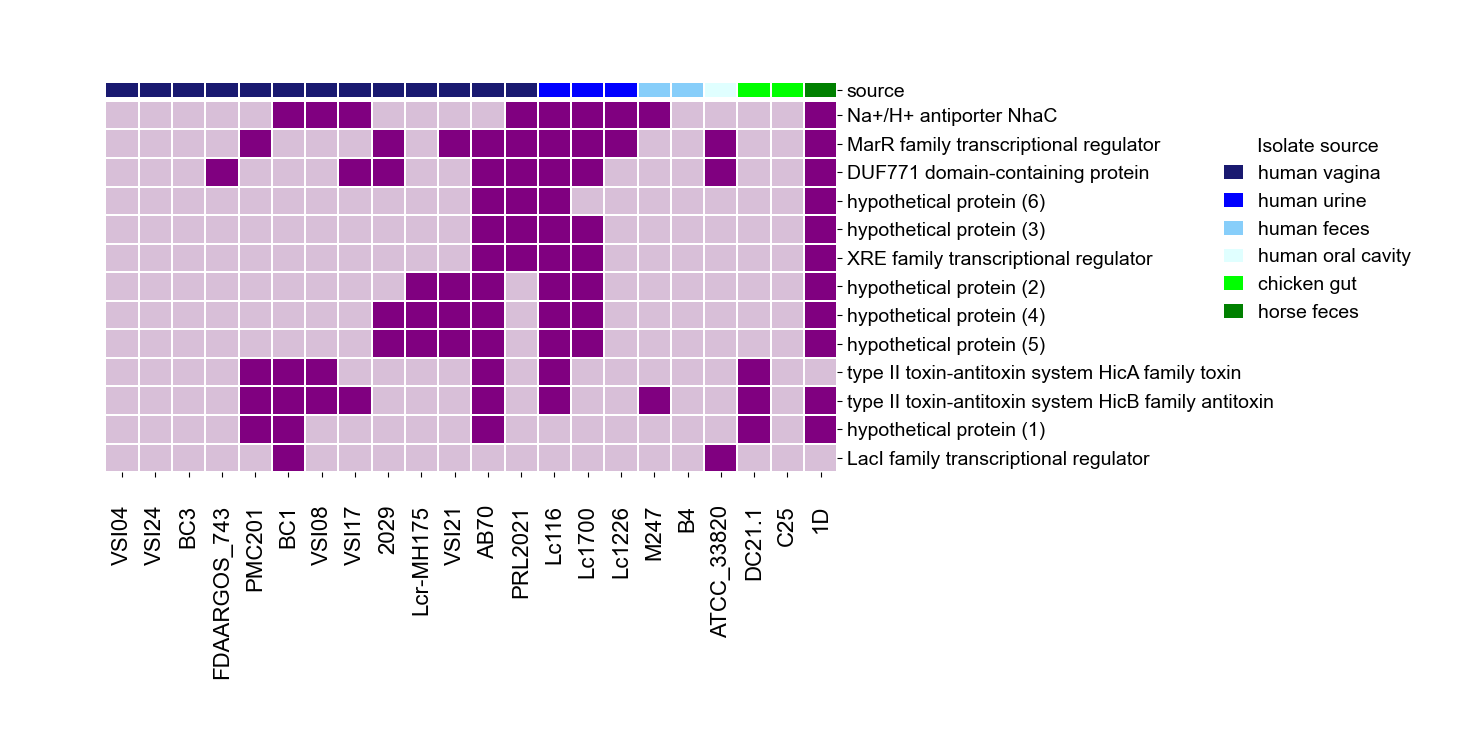

In [26]:
plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})

df = gene_pres_abs.T
df = df[col_order]
g = sns.clustermap(df.loc[strain_order].T, dendrogram_ratio=0.07, cbar_pos=None, figsize=(11.2, 6.5),
              col_colors=source_row_colors, 
              col_cluster=False,
              row_cluster=False,
                   cmap=['thistle','purple'],
                  linewidths=0.03, colors_ratio=0.04)

g.ax_heatmap.tick_params(axis='x', labelright=True,labelleft=False,
                        pad=20, labelsize=16)



g.ax_heatmap.set_yticklabels([ann_dict_simple[x.get_text()] for x in g.ax_heatmap.get_yticklabels()], rotation=0)


handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Isolate source', frameon=False,
           bbox_to_anchor=(1.3, 1), bbox_transform=plt.gcf().transFigure,
             loc='upper right', handletextpad=0.5, handlelength=1,
             labelspacing=0.3)

handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Isolate source', frameon=False,
           bbox_to_anchor=(1.25, 0.86), ncols=1, handlelength=1, bbox_transform=plt.gcf().transFigure, loc='upper right')
plt.xticks(fontsize=16)
plt.ylabel('')
plt.xlabel('')

ax = plt.gca()

fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_5A.png', format='png', dpi=600,bbox_inches = "tight")

plt.show()

### Functions for preparing plots

In [27]:

def get_strains_with_genes(gene_list, gbk_list):
    
    strains_with_genes = []
    blast_results_for_genes = blast_results[blast_results['subject_acc'].isin(gene_list)]
    for gbk in gbk_list:

        if gbk.name not in longest_seq_per_strain:
            continue
        features = gbk.extract_features("CDS")
        
        for f in features:

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                ann = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['annotation'].tolist()
                gene = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['subject_acc'].tolist()
                if gene[0] in gene_list:
                   strains_with_genes += [gbk.name]


    return strains_with_genes

In [28]:
def get_region_bounds(gene_list, gbk_list, strains_with_genes, to_reverse=[], window_size=2500):

    region_bounds = {}

    for gbk in gbk_list:

        if gbk.name not in strains_with_genes:
            continue
        features = gbk.extract_features("CDS")
        min_bound, max_bound = None, None
        found_genes = []
        for f in features:

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                gene = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['subject_acc'].tolist()[0]
                if gene in gene_list:
            
                    gene_start, gene_stop = f.location.start, f.location.end
                    if 'Lc1700' in gbk.name:
                        print(gene, gene_start, gene_stop)
                    if gene in found_genes:
                        print(f'skipping additional copy of {gene} in {gbk.name}: ({gene_start, gene_stop})')
                        continue
                    if not min_bound and not max_bound:
                        min_bound = min(gene_start, gene_stop)
                        max_bound = max(gene_start, gene_stop)
                    else:
                        min_bound = min(min_bound, gene_start, gene_stop )
                        max_bound = max(max_bound, gene_start, gene_stop )
                    found_genes += [gene]
                

        region_bounds[gbk.name] = (max(0, min_bound-window_size), int(max_bound+window_size))


    return region_bounds

In [29]:
def make_gbk_subset_files(region_bounds):

    #subset GBK files to regions with relevant genes (so it doesn't have to align whole genomes every time)

    input_dir = "genomes_for_pyGenomeViz"
    output_dir = "genomes_for_pyGenomeViz" 

    new_files = []


    for gbk_name, (min_bound, max_bound) in region_bounds.items():
        
        strain = gbk_name.replace('_copy','')    
        gbk_path = os.path.join(input_dir, f"{strain}.gbff")

        if 'copy' in gbk_name:
            !cp {gbk_path} {gbk_path.replace(strain, gbk_name)} 
            gbk_path = gbk_path.replace(strain, gbk_name)
            strain += '_copy'
        
        if not os.path.exists(gbk_path):
            print(f"Warning: {gbk_path} not found. Skipping.")
            continue

        # Read the GenBank file
        records = list(SeqIO.parse(gbk_path, "genbank"))
        if not records:
            print(f"Warning: No records found in {gbk_path}.")
            continue

        record = records[0]
        seq_len = len(record.seq)

        # Handle circular genomes (wrap-around)
        start = max(min_bound, 0)
        end = min(max_bound, seq_len)

        filtered_features = []
        for feat in record.features:
            if not feat.location:
                continue
            # Check if feature overlaps region
            if feat.location.end >= start and feat.location.start <= end:
                filtered_features.append(feat)

        # Create new record
        new_record = record[start:end]  # slices sequence and features
        new_record.features = filtered_features

        output_path = os.path.join(
            output_dir, f"{strain}_subset_{start}_{end}.gbff"
        )
        new_files += [output_path]
        SeqIO.write(new_record, output_path, "genbank")
        # print(f"Saved {output_path}")

    return new_files




###  Very long function for plotting

In [30]:
    
def plot_region(region_bounds, new_files,fig_width=10,
                align_coords=None, plot_labels=True, 
                print_labels=True, plot_track_names=True, operons_to_flip=[]):
    
    # gbk_list = list(map(Genbank, new_files))
    gbk_list = list(map(Genbank, [g.split('_subset')[0]+'.gbff' for g in new_files]))

    
    to_align = [gbk for gbk in gbk_list if gbk.name.split('_subset')[0] in region_bounds]

    adj_region_to_plot = {}
    for gbk in to_align:

    # for gbk in gbk_list:

        strain = gbk.name.split('_subset')[0]
        region_to_plot = region_bounds[strain]
        adj_region_to_plot[gbk.name] = region_to_plot
    
    if not align_coords:
        align_coords = MMseqs(to_align, cmd_opts="-c 0.75 --min-seq-id 0.75").run()
        align_coords = AlignCoord.filter(align_coords,  identity_thr=75)

    ref_names = []

    ### ALIGN FOR SYNTENY ANALYSIS

    if len(align_coords) > 0:
        min_ident = int(min([ac.identity for ac in align_coords if ac.identity]))
        for ac in align_coords:
            
            query_region = adj_region_to_plot[ac.query_id]
            ref_region = adj_region_to_plot[ac.ref_id]

            if ac.query_start in range(query_region[0], query_region[1]) and \
                ac.query_end in range(query_region[0], query_region[1]) and \
                ac.ref_start in range(ref_region[0], ref_region[1]) and \
                ac.ref_end in range(ref_region[0], ref_region[1]):
            
                ref_locus_name = '|'.join([ac.ref_link[0],
                                            str(ac.ref_link[2]),
                                                str(ac.ref_link[3])])
                                            
                ref_locus_name_rev = '|'.join([ac.ref_link[0],
                                                str(ac.ref_link[3]),
                                                    str(ac.ref_link[2])])

                ref_names += [ref_locus_name,ref_locus_name_rev ]

    coord_colors = {} 
    gv = GenomeViz(track_align_type="center", fig_track_height=0.35, fig_width=fig_width, feature_track_ratio=0.75)
    gv.set_scale_bar(labelsize=12, scale_size_label=(1000, '1 kb'))

    ### PLOT CDS FEATURES

    for gbk in to_align:

        # print(gbk.name)
        region_to_plot = adj_region_to_plot[gbk.name]
        features = gbk.extract_features("CDS", target_range=region_to_plot)
        track = gv.add_feature_track(gbk.name, align_label=True, segments=region_to_plot, 
                                    label_kws={'ha':'center'}, line_kws={'lw':0.5, 'color':'gray'})
        segment = track.get_segment()

        track_name = f'{gbk.name.replace('_copy','').split('_')[0]}\n{region_to_plot[0]}...{region_to_plot[1]}'
        if not plot_track_names:
            track.set_label('')
        # print()
        # print(track_name)
    
        for f in features:

            color = "#f0ae7d"
            label=''
            feature_name = '|'.join([gbk.name,str(f.location.start),str(f.location.end)])
            feature_name_rev = '|'.join([gbk.name,str(f.location.end),str(f.location.start)])
            
            if feature_name not in ref_names:
                label = f.qualifiers['product'][0]


            if f.qualifiers['product'][0] == 'hypothetical protein':
                label=''
                color='slategray'
                
            if 'transposase' in f.qualifiers['product'][0]:
                label=''
                color='palegoldenrod'

       

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                color = 'purple'

                # if feature_name not in ref_names:
                #     label= locus_to_ann[f.qualifiers['locus_tag'][0]]


            vpos = 'top'
            if f.location.strand == -1:
                vpos = 'bottom'


            if len(label) > 16:
                label = "\n".join(textwrap.wrap(label, width=16))

            if print_labels and len(label) > 0:
                print(label)
            if 'AB70' in gbk.name:
                print(f.qualifiers['product'][0])
                print(f.qualifiers['locus_tag'][0])

            if not plot_labels:
                label=''

            segment.add_feature(int(f.location.start), int(f.location.end), f.location.strand, 
                                    fc=color,  plotstyle="arrow",lw=0, label=label,
                                    arrow_shaft_ratio=1, alpha=1,
                                    text_kws=dict(rotation=0, size=7,hpos='center',vpos=vpos, ymargin=0.2, font='arial'))
            coord_colors[feature_name] = color
            coord_colors[feature_name_rev] = color


    ### PLOT LINKS ACROSS STRAINS

    if len(align_coords) > 0:
        
        min_ident = int(min([ac.identity for ac in align_coords if ac.identity]))
        for ac in align_coords:

            query_region = adj_region_to_plot[ac.query_id]
            ref_region = adj_region_to_plot[ac.ref_id]

            if ac.query_start in range(query_region[0], query_region[1]) and \
                ac.query_end in range(query_region[0], query_region[1]) and \
                ac.ref_start in range(ref_region[0], ref_region[1]) and \
                ac.ref_end in range(ref_region[0], ref_region[1]):


                    query_locus_name = '|'.join([ac.query_link[0],
                                        str(ac.query_link[2]),
                                            str(ac.query_link[3])])

                    if query_locus_name in coord_colors:
                        color = coord_colors[query_locus_name]

                    else:
                        query_locus_name_rev = '|'.join([ac.query_link[0],
                                                str(ac.query_link[3]),
                                                    str(ac.query_link[2])])

                        if query_locus_name_rev in coord_colors:
                            color = coord_colors[query_locus_name_rev]

                        else:
                            print(query_locus_name,query_locus_name_rev )
                            color ='pink'

                    gv.add_link(ac.query_link[:1]+ac.query_link[2:], ac.ref_link[:1]+ac.ref_link[2:], 
                            color='silver', inverted_color='silver', v=ac.identity, vmin=min_ident, alpha=0.3, curve=True)
        

    ### PLOT OPERONS
    function_list = []
    operons_to_plot = {}
    for track, gbk in zip(gv.feature_tracks, to_align):

        region_to_plot = adj_region_to_plot[gbk.name] 
        strain = gbk.name.split('_subset')[0].replace('_copy','')
        segment = track.get_segment()
        operons_to_plot[gbk.name] = []
        if 'ATCC' in strain:
            strain='ATCC_33820'

        f = !ls operon_mapper_outputs/{strain}/list_of_operons_*
        if f[0].startswith('operon_mapper_outputs'):
            strain_range = range(region_to_plot[0], region_to_plot[1])
            predicted_operons = pd.read_csv(f[0], sep='\t')
            predicted_operons['Operon'] = predicted_operons['Operon'].ffill()
            predicted_operons = predicted_operons.dropna(subset=['IdGene', 'Type', 'COGgene', 'PosLeft', 'postRight', 'Strand', 'Function'], how='all')
            predicted_operons = predicted_operons.reset_index(drop=True)
        

            if  strain in operons_to_flip:
                #reversed some genomes to they are aligned the same as others, also need to flip operons

                seq_len = total_seq_lens[gbk.name.split('_')[0]]
                predicted_operons['PosLeft_new'] = seq_len-predicted_operons['PosLeft']
                predicted_operons['postRight_new'] = seq_len-predicted_operons['postRight']
                predicted_operons = predicted_operons.drop(columns=['PosLeft','postRight']).rename(columns={'PosLeft_new':'postRight', 'postRight_new':'PosLeft'})
                predicted_operons['Strand'] = predicted_operons['Strand'].str.replace('+','neg').str.replace('-','+').str.replace('neg','-')
            
            predicted_operons = predicted_operons[(predicted_operons['PosLeft'].isin(strain_range)) | 
                                                (predicted_operons['postRight'].isin(strain_range))]
            left_bounds = predicted_operons.groupby('Operon')['PosLeft'].min()
            right_bounds = predicted_operons.groupby('Operon')['postRight'].max()
            operon_bounds = pd.DataFrame(left_bounds).merge(pd.DataFrame(right_bounds), left_index=True, right_index=True)
            operon_bounds['Strand'] = operon_bounds.index.map(predicted_operons.drop_duplicates('Operon').set_index('Operon')['Strand'])
            predicted_operons['loc'] = predicted_operons['postRight'].astype(str) + '_' + predicted_operons['PosLeft'].astype(str) + '_' + predicted_operons['Strand']
            cds_to_function = predicted_operons.set_index('loc')['Function'].to_dict()
            cds_to_function = {
                k: (v.split(']')[0].strip('[') if not pd.isna(v) else 'N/A')
                for k, v in cds_to_function.items()
            }


            for o, row in operon_bounds.iterrows():
                if row['PosLeft'] in range(region_to_plot[0], region_to_plot[1]) or row['postRight'] in range(region_to_plot[0], region_to_plot[1]):
                    start, end = int(row['PosLeft']), int(row['postRight'])
                    
                    for cds_locus in coord_colors.keys():
                        # if cds_locus.split('_subset')[0] != strain:
                        if cds_locus.split('|')[0] != strain:
                            continue
                        cds_start, cds_end = float(cds_locus.split('|')[1]), float(cds_locus.split('|')[2])
                        if getOverlap((start,end), (cds_start, cds_end)) > 0:
                            operons_to_plot[gbk.name] += [f'{start}|{end}|{row['Strand']}']        

                            for operon_cds, function in cds_to_function.items():

                                    operon_cds_start, operon_cds_end, operon_cds_strand = float(operon_cds.split('_')[0]), float(operon_cds.split('_')[1]), operon_cds.split('_')[2]
                                    if getOverlap((min(operon_cds_start,operon_cds_end), max(operon_cds_start,operon_cds_end)), (cds_start, cds_end)) > 0:
                                            
                                            if coord_colors[cds_locus] not in ['purple','slategray']:
                                                
                                                function_list += [function]
                                                strand = 1
                                                if operon_cds_strand == '-':
                                                    strand = -1
                       
    fig = gv.plotfig()

    
    for track, gbk in zip(gv.feature_tracks, to_align):
        
        region_to_plot = adj_region_to_plot[gbk.name] 
        strain = gbk.name.split('_')[0]
        
        for operon_info in set(operons_to_plot[gbk.name]):
            start, end, strand = operon_info.split('|')
            start, end = int(start), int(end)
            start, end = track.transform_coord(max(start, region_to_plot[0])), track.transform_coord(min(end, region_to_plot[1]))
            if strand == '+':
                y_bounds = (0, 0, 1, 1)
                y_offset = -0.2
            else:
                y_bounds = (-1, -1, 0, 0)
                y_offset = 0.2

            x, y = (start, end, end, start), y_bounds
            track.ax.hlines(y=y_offset, xmin=start, xmax=end, 
                            color="sienna", lw=3, clip_on=False, alpha=0.7)


    # g = gv.plotfig(fast_render=False)
    # fig.savefig("/Users/cdubin/Desktop/result3.png", dpi=600)
    # fig.savefig_html("/Users/cdubin/Desktop/result2.html")
    # gv.savefig_html("coverage_plot.html", fig)

    fig = gv.plotfig()
    plt.show()

    return align_coords, fig

### Plots for groups of 3 hypothetical proteins

In [38]:

#flipping around these genomes so they are oriented the same as the other ones
to_reverse = [
    'Lcr-MH175',
    # 'VSI21',
    # '2029',
    # '1D',
]


for strain in to_reverse:

    !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
    !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
    !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

Found 1 contig(s) in the file
Processing contig 1/1
Processing contig with length: 2471292
Successfully reversed genomes_for_pyGenomeViz/Lcr-MH175.gbff -> genomes_for_pyGenomeViz/Lcr-MH175_rev.gbff


7
skipping additional copy of ERR10897979.sbin.2_00762 in Lc116: ((ExactPosition(1031900), ExactPosition(1032509)))
skipping additional copy of ERR10897595.sbin.1_01051 in Lc116: ((ExactPosition(1032632), ExactPosition(1033052)))
skipping additional copy of ERR10897583.sbin.2_00776 in Lc116: ((ExactPosition(1033063), ExactPosition(1033315)))
ERR10897979.sbin.2_00762 546961 547570
ERR10897595.sbin.1_01051 547693 548113
ERR10897583.sbin.2_00776 548125 548377
skipping additional copy of ERR10897595.sbin.1_01051 in Lcr-MH175: ((ExactPosition(516689), ExactPosition(517106)))
skipping additional copy of ERR10897583.sbin.2_00776 in Lcr-MH175: ((ExactPosition(516426), ExactPosition(516678)))
pyocin knob
domain-
containing
protein
XkdX family
protein
phage holin
lysin
hypothetical protein
C3K22_05465
hypothetical protein
C3K22_05470
hypothetical protein
C3K22_05475
hypothetical protein
C3K22_05480
XkdX family protein
C3K22_05485
hypothetical protein
C3K22_05490
hypothetical protein
C3K22_05495


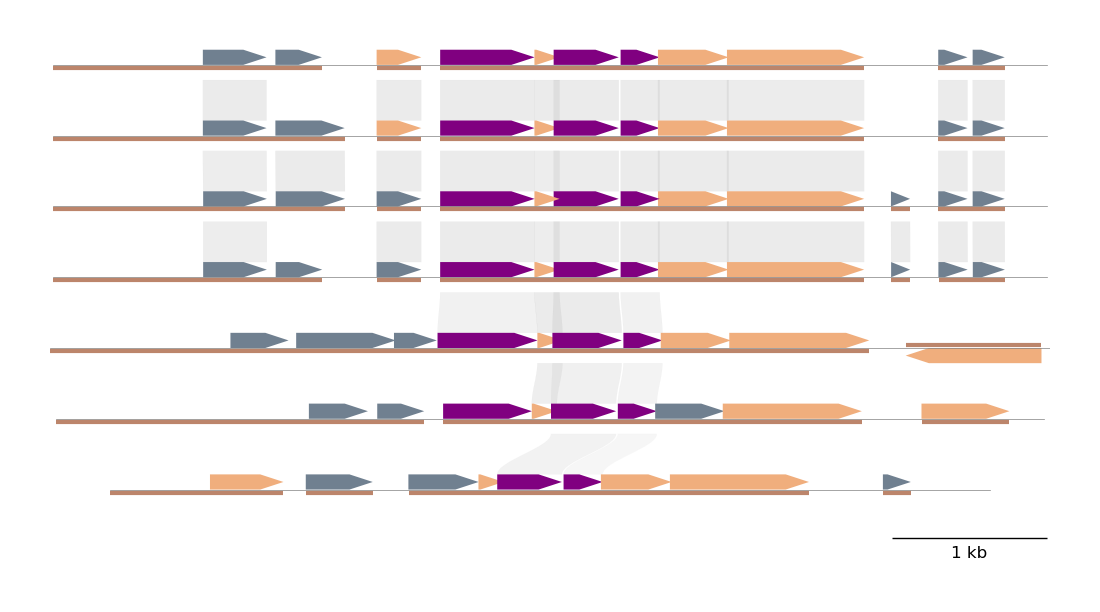

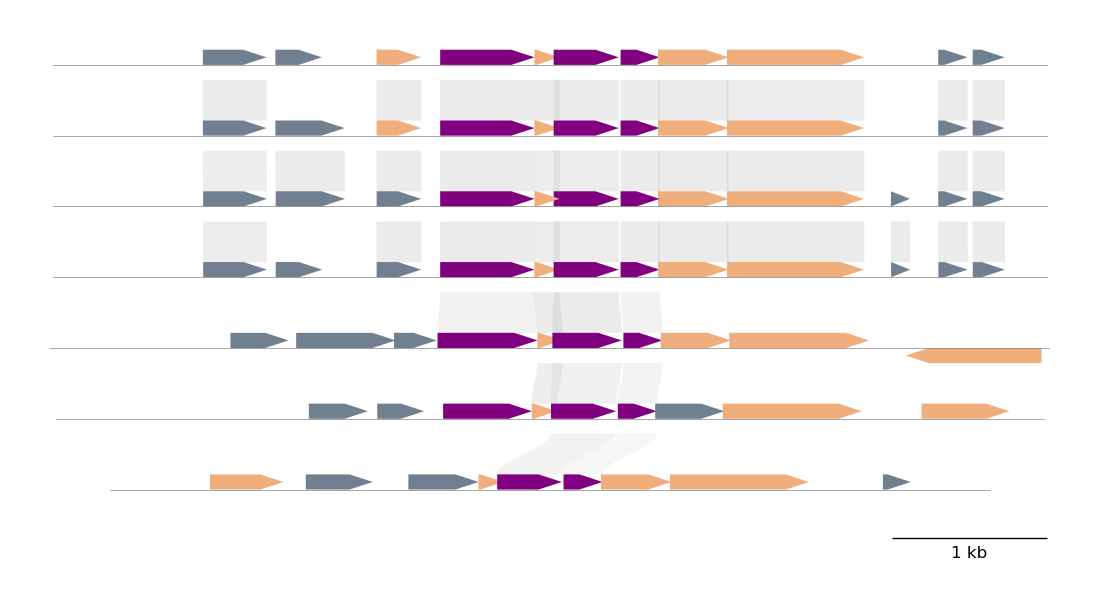

In [39]:
gene_list = ['ERR10897979.sbin.2_00762', 'ERR10897595.sbin.1_01051',
             'ERR10897583.sbin.2_00776']
gbk_list = list(map(Genbank, gbk_files))

strains_with_genes = get_strains_with_genes(gene_list, gbk_list)
print(len(set(strains_with_genes)))
region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes, 
# to_reverse = ['Lcr-MH175']
)

# region_bounds['Lcr-MH175'] = (268106-2500, 269599+2500)
# region_bounds['Lc116'] = (440147-2500, 441640+2500)

new_files = make_gbk_subset_files(region_bounds)

# new_files = [i for i in new_files if 'Lc116' not in i and 'MH175' not in i]


new_files = [
     'genomes_for_pyGenomeViz/Lc1700_subset_544384_550877.gbff',
 'genomes_for_pyGenomeViz/Lc116_subset_437647_444140.gbff',
 'genomes_for_pyGenomeViz/Lcr-MH175_subset_2199271_2205687.gbff',
 'genomes_for_pyGenomeViz/VSI21_subset_545247_551740.gbff',
'genomes_for_pyGenomeViz/AB70_subset_1062687_1068754.gbff',
    'genomes_for_pyGenomeViz/1D_subset_1097898_1104378.gbff',
      'genomes_for_pyGenomeViz/2029_subset_1164861_1170503.gbff',

 ]

align_coords, fig = plot_region(region_bounds, new_files,
                                 plot_track_names=False, 
                                 plot_labels=False, 
                                 fig_width=10,
                                 operons_to_flip=['Lcr-MH175']
                                 )

### Plots for 4 gene group including XRE family protein

In [114]:
# to_reverse = ['1D','2029','VSI17']
to_reverse = [
             'VSI17',
                # '1D',
                # '2029'
                ]
# to_reverse = ['VSI24']
# to_reverse = ['FDAARGOS_743']
# to_reverse = ['VSI17','2029']
# to_reverse = ['1D','2029']


for strain in to_reverse:

    !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
    !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
    !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

Found 1 contig(s) in the file
Processing contig 1/1
Processing contig with length: 2455419
Successfully reversed genomes_for_pyGenomeViz/VSI17.gbff -> genomes_for_pyGenomeViz/VSI17_rev.gbff


12
ERR4421622.sbin.2_01193 1685371 1685965
ERR10897595.sbin.1_00593 1685957 1686344
ERR10897696.sbin.1_01201 1686414 1686759
ERR10897595.sbin.1_00591 1686761 1687493
(1574585, 1579930)
(2275392, 2280737)
12
hypothetical protein
C3K22_08575
hypothetical protein
C3K22_08580
single-stranded
DNA-binding
protein
single-stranded DNA-binding protein
C3K22_08585
hypothetical protein
C3K22_08590
hypothetical protein
C3K22_08595
hypothetical protein
C3K22_08600
hypothetical protein
C3K22_08605
XRE family
transcriptional
regulator
XRE family transcriptional regulator
C3K22_08610
hypothetical protein
C3K22_08615
DUF771 domain-
containing
protein
DUF771 domain-containing protein
C3K22_08620
hypothetical protein
C3K22_08625
XRE family
transcriptional
regulator
XRE family transcriptional regulator
C3K22_08630
XRE family
transcriptional
regulator
XRE family transcriptional regulator
C3K22_08635
ImmA/IrrE family
metallo-
endopeptidase
ImmA/IrrE family metallo-endopeptidase
C3K22_08640
site-specific
int

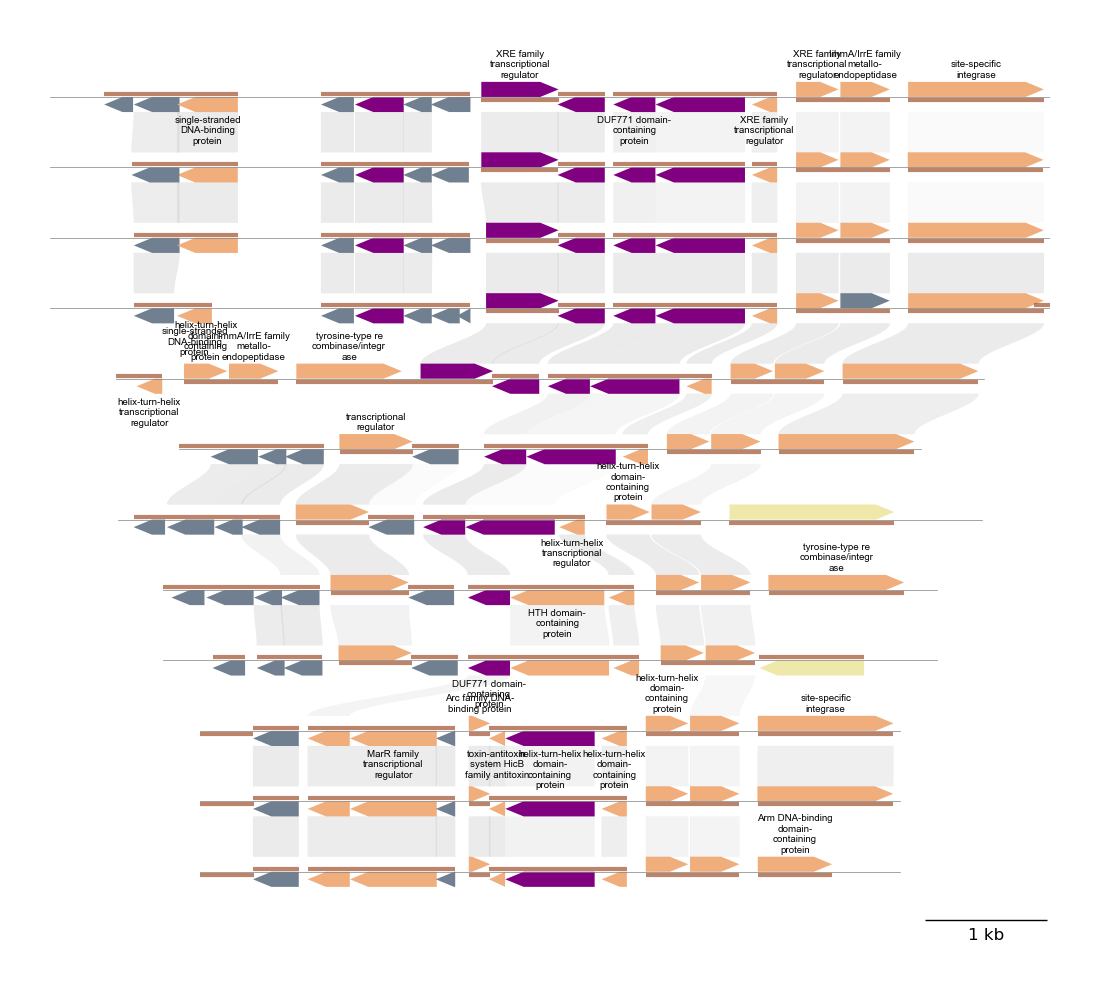

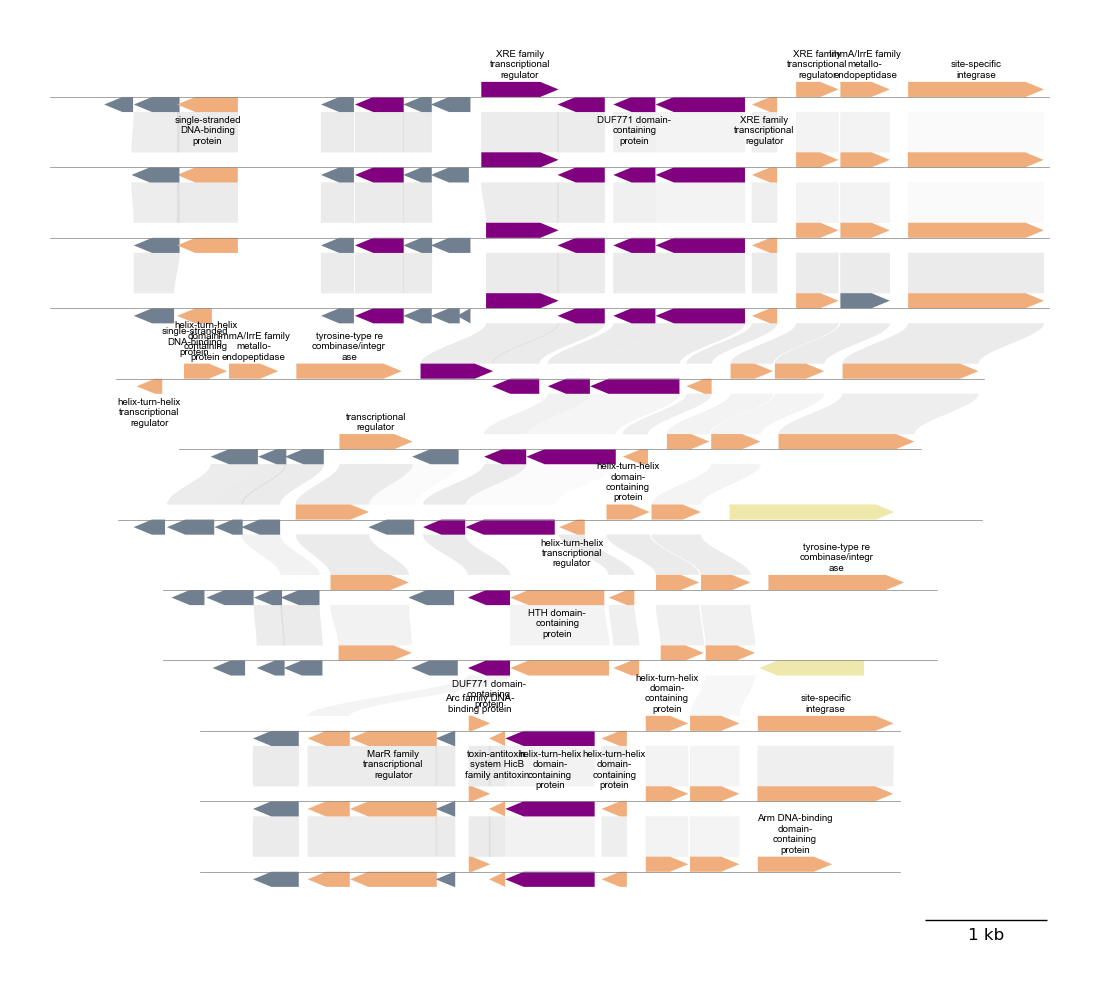

In [ ]:


gbk_list = list(map(Genbank, gbk_files))
gene_list = ['ERR10897696.sbin.1_01201','ERR10897595.sbin.1_00593',
             'ERR10897595.sbin.1_00598', 'ERR4421622.sbin.2_01193',
             'ERR10897595.sbin.1_00591'
             ]
strains_with_genes = get_strains_with_genes(gene_list, gbk_list)
print(len(set(strains_with_genes)))
region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes)

#splitting tracks because of duplicate genes in Lc1700
# region_bounds['Lc1700_copy'] = (1685371-2500, 1686759+2500)
# region_bounds['Lc1700'] = (1676001, 1689259)
print(region_bounds['VSI17'])
print(region_bounds['FDAARGOS_743'])

# region_bounds['Lc1700'] = (1682871, 1689259)

region_bounds['2029'] = (1748809, 1754888+1000)
region_bounds['FDAARGOS_743'] = (2275392, 2280737+1000)
region_bounds['VSI17'] = (1574585, 1579930+1000)


new_files = make_gbk_subset_files(region_bounds)


new_files = [
   'genomes_for_pyGenomeViz/AB70_subset_1659543_1667739.gbff',

  'genomes_for_pyGenomeViz/1D_subset_1860834_1869030.gbff',
 'genomes_for_pyGenomeViz/Lc116_subset_1593189_1601385.gbff',
 'genomes_for_pyGenomeViz/PRL2021_subset_1692220_1700416.gbff',
 'genomes_for_pyGenomeViz/Lc1700_subset_1682871_1689993.gbff',
 'genomes_for_pyGenomeViz/ATCC_33820_subset_1537146_1543225.gbff',
   'genomes_for_pyGenomeViz/2029_subset_1748809_1754888.gbff',
     'genomes_for_pyGenomeViz/FDAARGOS_743_subset_2275392_2280737.gbff',
 'genomes_for_pyGenomeViz/VSI17_subset_1574585_1579930.gbff',
 'genomes_for_pyGenomeViz/PMC201_subset_1636891_1642623.gbff',
  'genomes_for_pyGenomeViz/VSI21_subset_1716643_1722375.gbff',
 'genomes_for_pyGenomeViz/Lc1226_subset_1767061_1772793.gbff',


 ]
print(len(new_files))

align_coords, fig = plot_region(region_bounds, 
                      
                                new_files, 
                                fig_width=10,
                                plot_track_names=False, 
                                # plot_labels=False, 
                                operons_to_flip=['1D', '2029', 'VSI17', 'Lcr-MH175', 'PMC201'])


### Hypothetical protein 1

In [91]:
to_reverse = ['DC21.1',
# '1D'
]

for strain in to_reverse:

    !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
    !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
    !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

Found 2 contig(s) in the file
Processing contig 1/2
Processing contig with length: 2023061
Processing contig 2/2
Processing contig with length: 16343
Successfully reversed genomes_for_pyGenomeViz/DC21.1.gbff -> genomes_for_pyGenomeViz/DC21.1_rev.gbff


DUF871 family
protein
oligosaccharide
flippase family
protein
polysaccharide
biosynthesis
C-terminal
domain-
containing
protein
GNAT family N-
acetyltransferas
e
hypoxanthine pho
sphoribosyltrans
ferase
TetR/AcrR family
transcriptional
regulator
TetR/AcrR family transcriptional regulator
C3K22_10590
hypoxanthine phosphoribosyltransferase
C3K22_10595
N-acetyltransferase
C3K22_10600
hypothetical protein
C3K22_10605
hypothetical protein
C3K22_10610
hypothetical protein
C3K22_10615
hypothetical protein
C3K22_10620
hypothetical protein
C3K22_10625
linear amide C-N
hydrolase
linear amide C-N
hydrolase
ATP-binding
protein
linear amide C-N
hydrolase
linear amide C-N
hydrolase
PMC201|2043553|2043852 PMC201
PMC201|2043852|2043553 PMC201
PMC201|2043313|2043604 PMC201
PMC201|2043604|2043313 PMC201
PMC201|2042716|2043118 PMC201
PMC201|2043118|2042716 PMC201
PMC201|2042365|2042641 PMC201
PMC201|2042641|2042365 PMC201
PMC201|2040110|2042258 PMC201
PMC201|2042258|2040110 PMC201
PMC201|2039530|2040094 

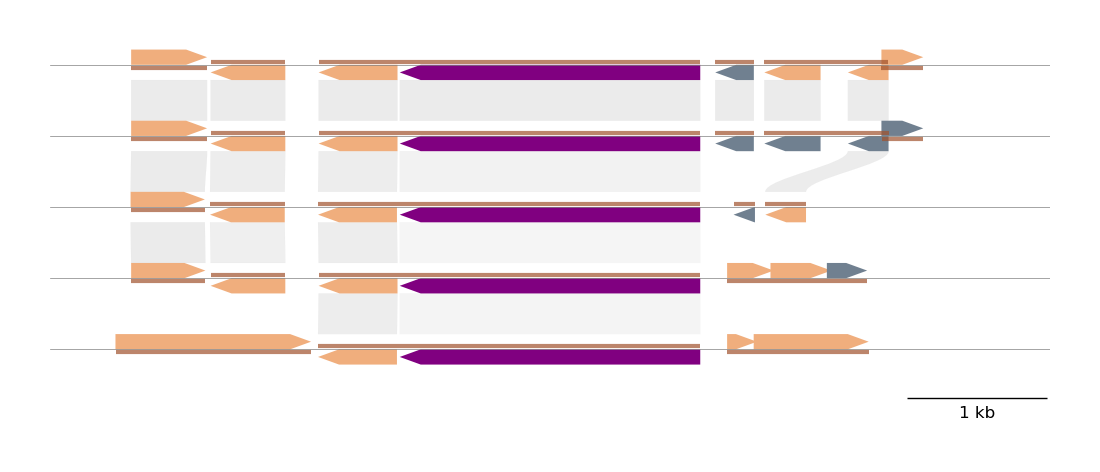

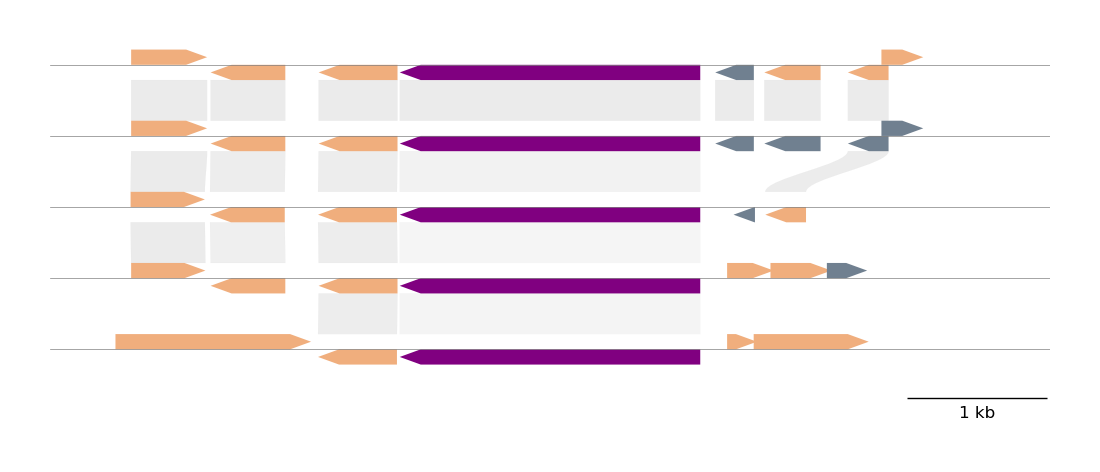

In [92]:


gbk_list = list(map(Genbank, gbk_files))
gene_list = ['MG334.mbin.2_00182']
strains_with_genes = get_strains_with_genes(gene_list, gbk_list)

region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes)
new_files = make_gbk_subset_files(region_bounds)

new_files = [
      'genomes_for_pyGenomeViz/PMC201_subset_2037610_2044758.gbff',
 'genomes_for_pyGenomeViz/AB70_subset_2062045_2069193.gbff',
 'genomes_for_pyGenomeViz/BC1_subset_1796545_1803693.gbff',
       'genomes_for_pyGenomeViz/1D_subset_2050331_2057479.gbff',
 'genomes_for_pyGenomeViz/DC21.1_subset_1710894_1718042.gbff',
]

align_coords, fig = plot_region(region_bounds, 
                                new_files, 
                                fig_width=10,
                                plot_track_names=False, 
                                plot_labels=False, 
                                operons_to_flip=['PMC201'])


### Toxin-antitoxin 

In [46]:
# to_reverse = ['DC21.1']
to_reverse = ['1D', 'VSI17']

for strain in to_reverse:

    !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
    !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
    !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

Found 1 contig(s) in the file
Processing contig 1/1
Processing contig with length: 2349358
Successfully reversed genomes_for_pyGenomeViz/1D.gbff -> genomes_for_pyGenomeViz/1D_rev.gbff
Found 1 contig(s) in the file
Processing contig 1/1
Processing contig with length: 2455419
Successfully reversed genomes_for_pyGenomeViz/VSI17.gbff -> genomes_for_pyGenomeViz/VSI17_rev.gbff


9
9
ABC transporter
C3K22_03695
hypothetical protein
C3K22_03700
type II toxin-antitoxin system HicA family toxin
C3K22_03705
type II toxin-antitoxin system HicB family antitoxin
C3K22_03710
hypothetical protein
C3K22_03715
hypothetical protein
C3K22_03720
transposase
C3K22_03725
Lc116|664569|665559 Lc116
Lc116|665559|664569 Lc116
Lc116|665916|666162 Lc116
Lc116|666162|665916 Lc116
Lc116|666161|666497 Lc116
Lc116|666497|666161 Lc116
Lc116|666544|666763 Lc116
Lc116|666763|666544 Lc116
Lc116|666772|667048 Lc116
Lc116|667048|666772 Lc116
Lc116|667429|668302 Lc116
Lc116|668302|667429 Lc116
Lc116|668388|668520 Lc116
Lc116|668520|668388 Lc116
DC21.1|1477228|1477618 Lc116
DC21.1|1477618|1477228 Lc116
DC21.1|1477877|1478704 Lc116
DC21.1|1478704|1477877 Lc116
DC21.1|1478952|1479228 Lc116
DC21.1|1479228|1478952 Lc116
DC21.1|1479237|1479456 Lc116
DC21.1|1479456|1479237 Lc116
DC21.1|1479503|1479839 Lc116
DC21.1|1479839|1479503 Lc116
DC21.1|1479838|1480084 Lc116
DC21.1|1480084|1479838 Lc116
DC21.1|

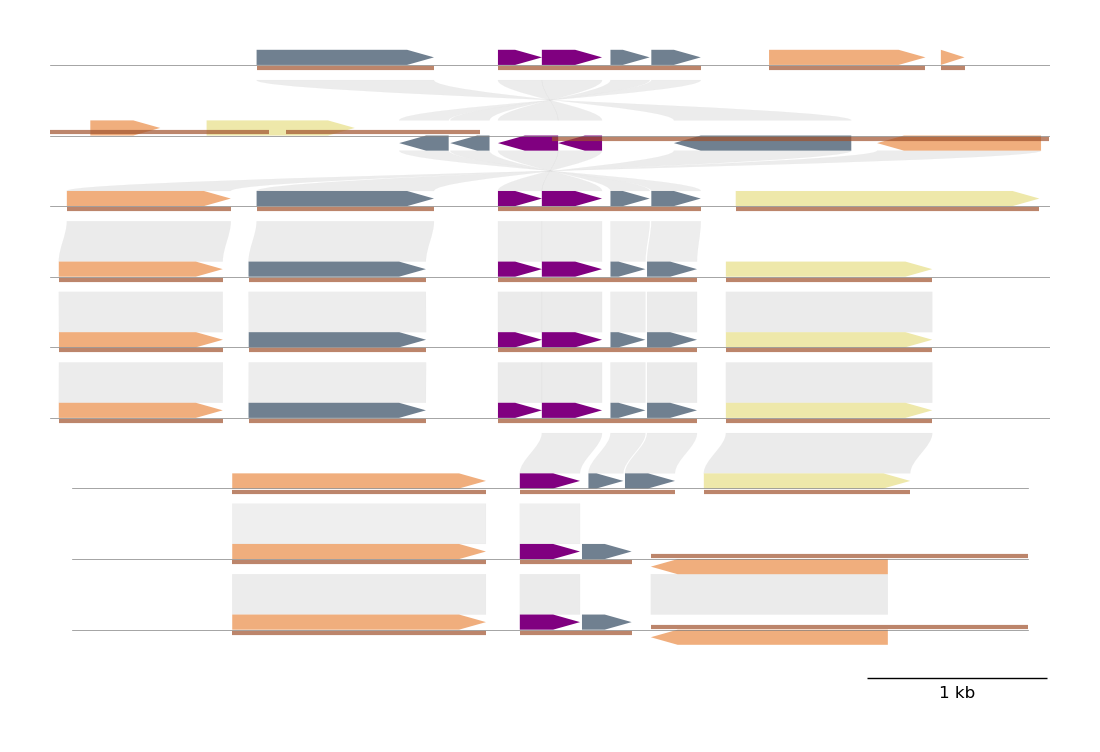

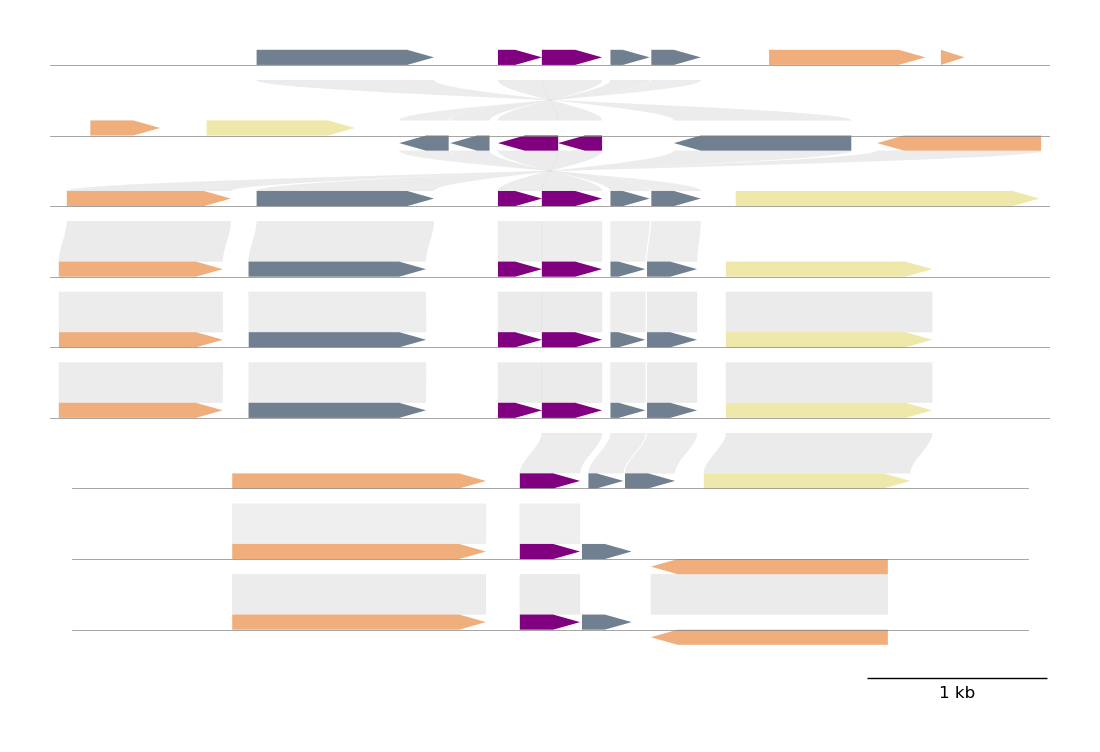

In [98]:


gbk_list = list(map(Genbank, gbk_files))
gene_list = ['ERR10897723.sbin.1_00478','ERR10897583.sbin.2_00437']
strains_with_genes = get_strains_with_genes(gene_list, gbk_list)
print(len(set(strains_with_genes)))

region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes)
new_files = make_gbk_subset_files(region_bounds)
# new_files = [
#      'genomes_for_pyGenomeViz/BC1_subset_650146_655392.gbff',
#     'genomes_for_pyGenomeViz/AB70_subset_694319_699565.gbff',
#      'genomes_for_pyGenomeViz/PMC201_subset_714826_720072.gbff',
#  'genomes_for_pyGenomeViz/DC21.1_subset_540477_545723.gbff',
#  'genomes_for_pyGenomeViz/VSI08_subset_725826_731072.gbff',
#   'genomes_for_pyGenomeViz/Lc116_subset_663416_668662.gbff',
# ]

new_files = [
    'genomes_for_pyGenomeViz/Lc116_subset_663416_668997.gbff',
 'genomes_for_pyGenomeViz/DC21.1_subset_540477_546058.gbff',

  'genomes_for_pyGenomeViz/VSI08_subset_725826_731407.gbff',
 'genomes_for_pyGenomeViz/AB70_subset_694319_699900.gbff',
 'genomes_for_pyGenomeViz/BC1_subset_650146_655727.gbff',
  'genomes_for_pyGenomeViz/PMC201_subset_714826_720407.gbff',
 
   'genomes_for_pyGenomeViz/1D_subset_762066_767402.gbff',
 'genomes_for_pyGenomeViz/VSI17_subset_726498_731834.gbff',
  'genomes_for_pyGenomeViz/M247_subset_725839_731175.gbff',
 ]
print(len(new_files))

align_coords, fig = plot_region(region_bounds, 
                                new_files, 
                                fig_width=10,
                                plot_track_names=False, 
                                plot_labels=False, 
                                print_labels=False,
                                operons_to_flip=['PMC201','DC21.1'],
                                )


### LacI repressor

alpha-xylosidase
LacI family DNA-
binding
transcriptional
regulator
extracellular
solute-binding
protein
ATCC_33820|690167|692375 ATCC_33820
ATCC_33820|692375|690167 ATCC_33820
ATCC_33820|692367|693366 ATCC_33820
ATCC_33820|693366|692367 ATCC_33820
ATCC_33820|693369|694587 ATCC_33820
ATCC_33820|694587|693369 ATCC_33820
BC1|664616|666824 ATCC_33820
BC1|666824|664616 ATCC_33820
BC1|666816|667815 ATCC_33820
BC1|667815|666816 ATCC_33820
BC1|667818|669036 ATCC_33820
BC1|669036|667818 ATCC_33820
ATCC_33820|690167|692375 ATCC_33820
ATCC_33820|692375|690167 ATCC_33820
ATCC_33820|692367|693366 ATCC_33820
ATCC_33820|693366|692367 ATCC_33820
ATCC_33820|693369|694587 ATCC_33820
ATCC_33820|694587|693369 ATCC_33820
BC1|664616|666824 ATCC_33820
BC1|666824|664616 ATCC_33820
BC1|666816|667815 ATCC_33820
BC1|667815|666816 ATCC_33820
BC1|667818|669036 ATCC_33820
BC1|669036|667818 ATCC_33820
ATCC_33820|690167|692375 ATCC_33820
ATCC_33820|692375|690167 ATCC_33820
ATCC_33820|692367|693366 ATCC_33820
ATCC_33

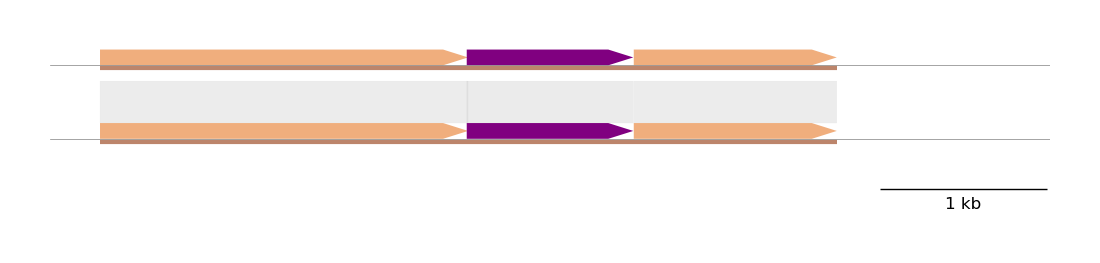

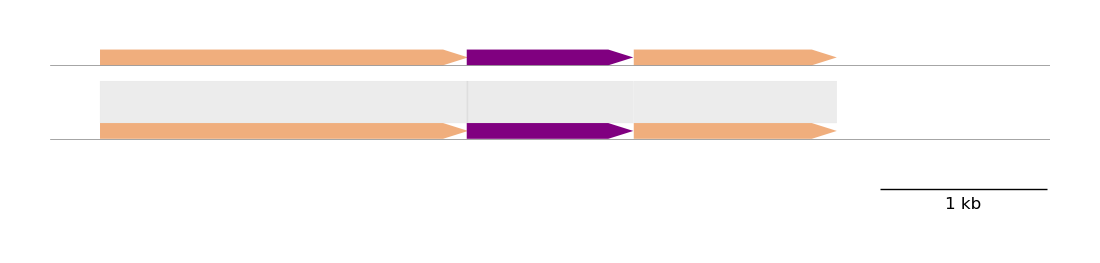

In [ ]:


gbk_list = list(map(Genbank, gbk_files))
gene_list = ['ERR10898139.sbin.1_00313',]
strains_with_genes = get_strains_with_genes(gene_list, gbk_list)

region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes)
new_files = make_gbk_subset_files(region_bounds)


align_coords, fig = plot_region(region_bounds, 
                                new_files, 
                                fig_width=10,
                                plot_track_names=False, 
                                plot_labels=False, 
                                operons_to_flip=['PMC201'],
                                )


### Sodium transporter

In [212]:
to_reverse = ['VSI17']

for strain in to_reverse:

    !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
    !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
    !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

Found 1 contig(s) in the file
Processing contig 1/1
Processing contig with length: 2455419
Successfully reversed genomes_for_pyGenomeViz/VSI17.gbff -> genomes_for_pyGenomeViz/VSI17_rev.gbff


9
SRR17635712.mbin.7_01059 1913582 1914956
9
serine hydrolase
sodium:proton
antiporter
Bax
inhibitor-1/YccA
family protein
PRL2021|1928984|1930019 PRL2021
PRL2021|1930019|1928984 PRL2021
PRL2021|1930416|1931790 PRL2021
PRL2021|1931790|1930416 PRL2021
PRL2021|1932729|1933077 PRL2021
PRL2021|1933077|1932729 PRL2021
BC1|1607743|1608778 PRL2021
BC1|1608778|1607743 PRL2021
BC1|1609176|1610550 PRL2021
BC1|1610550|1609176 PRL2021
BC1|1610633|1610912 PRL2021
BC1|1610912|1610633 PRL2021
BC1|1610908|1611451 PRL2021
BC1|1611451|1610908 PRL2021
BC1|1611564|1611912 PRL2021
BC1|1611912|1611564 PRL2021
BC1|1612073|1612784 PRL2021
BC1|1612784|1612073 PRL2021
1D|1860072|1861107 PRL2021
1D|1861107|1860072 PRL2021
1D|1861504|1862878 PRL2021
1D|1862878|1861504 PRL2021
1D|1863042|1863906 PRL2021
1D|1863906|1863042 PRL2021
1D|1863880|1864228 PRL2021
1D|1864228|1863880 PRL2021
1D|1864389|1865100 PRL2021
1D|1865100|1864389 PRL2021
VSI17|1911609|1912644 PRL2021
VSI17|1912644|1911609 PRL2021
VSI17|1913041|19144

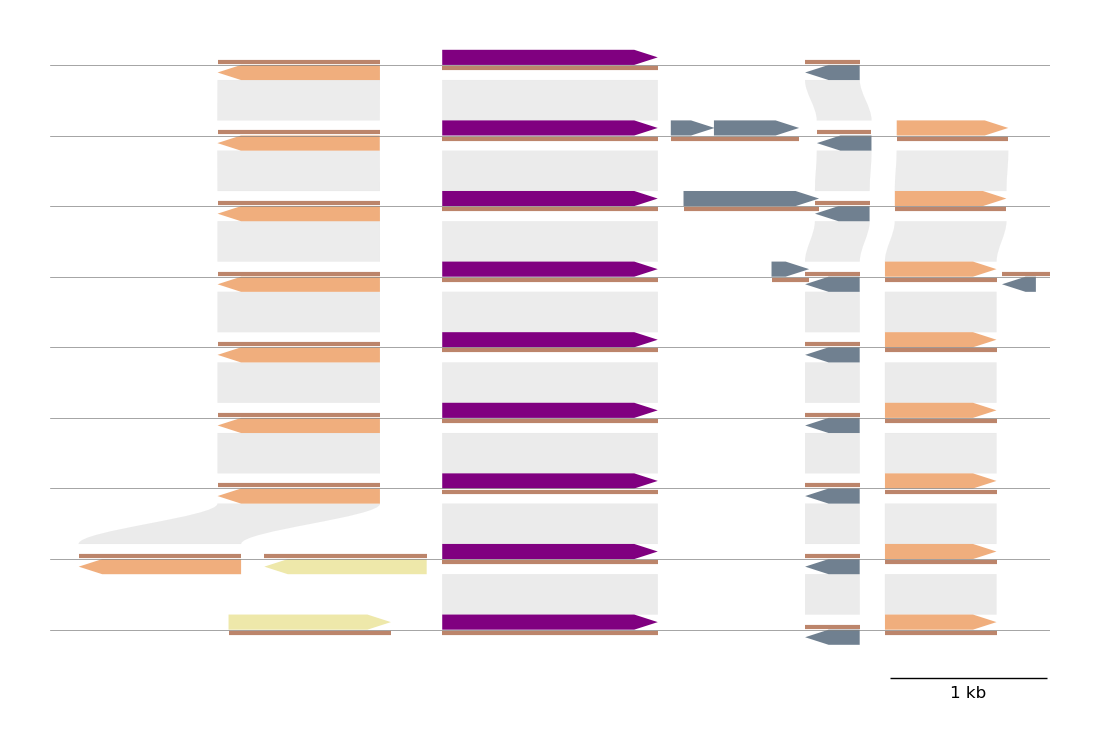

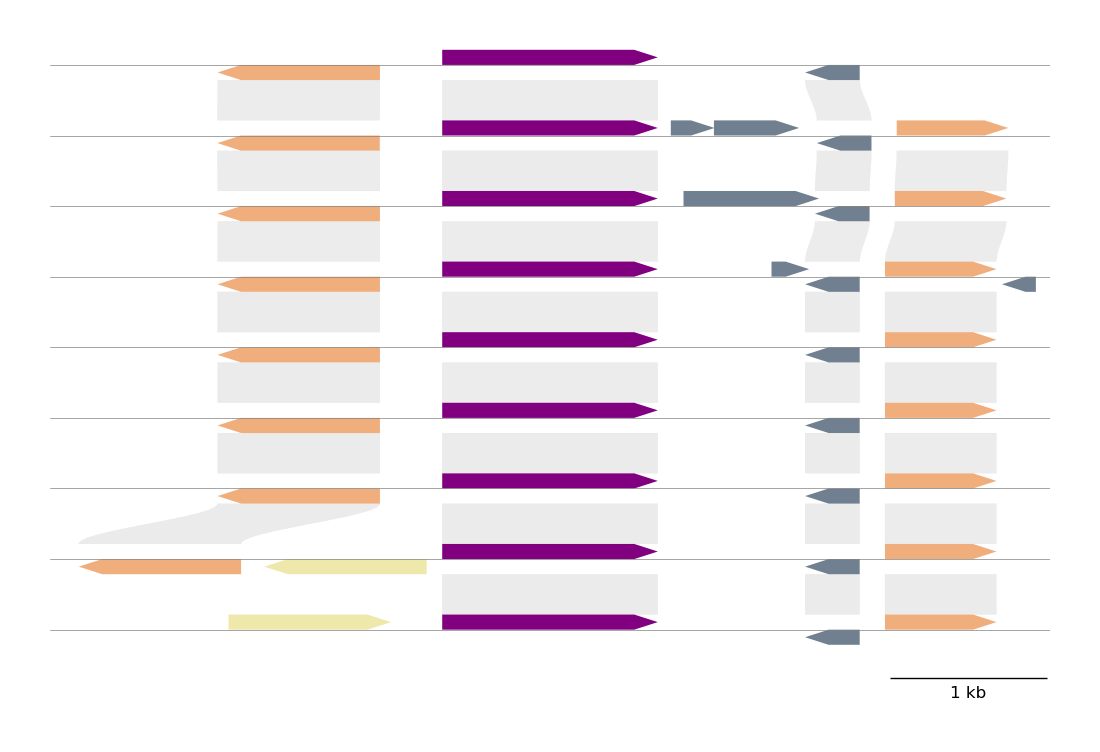

['genomes_for_pyGenomeViz/PRL2021_subset_1927916_1934290.gbff',
 'genomes_for_pyGenomeViz/BC1_subset_1606676_1613050.gbff',
 'genomes_for_pyGenomeViz/1D_subset_1859004_1865378.gbff',
 'genomes_for_pyGenomeViz/VSI17_subset_1910541_1916915.gbff',
 'genomes_for_pyGenomeViz/Lc116_subset_1818634_1825008.gbff',
 'genomes_for_pyGenomeViz/M247_subset_1780388_1786762.gbff',
 'genomes_for_pyGenomeViz/VSI08_subset_1816788_1823162.gbff',
 'genomes_for_pyGenomeViz/Lc1226_subset_1986713_1993087.gbff',
 'genomes_for_pyGenomeViz/Lc1700_subset_1911082_1917456.gbff']

In [97]:


gbk_list = list(map(Genbank, gbk_files))
gene_list = ['SRR17635712.mbin.7_01059']
strains_with_genes = get_strains_with_genes(gene_list, gbk_list)
print(len(set(strains_with_genes)))
region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes)
new_files = make_gbk_subset_files(region_bounds)
new_files = [
      'genomes_for_pyGenomeViz/PRL2021_subset_1927916_1934290.gbff',
 'genomes_for_pyGenomeViz/BC1_subset_1606676_1613050.gbff',
    'genomes_for_pyGenomeViz/1D_subset_1859004_1865378.gbff',
  'genomes_for_pyGenomeViz/VSI17_subset_1910541_1916915.gbff',
 'genomes_for_pyGenomeViz/Lc116_subset_1818634_1825008.gbff',
 'genomes_for_pyGenomeViz/M247_subset_1780388_1786762.gbff',
 'genomes_for_pyGenomeViz/VSI08_subset_1816788_1823162.gbff',
  'genomes_for_pyGenomeViz/Lc1226_subset_1986713_1993087.gbff',
     'genomes_for_pyGenomeViz/Lc1700_subset_1911082_1917456.gbff',

 ]
print(len(new_files))


align_coords, fig = plot_region(region_bounds, 
                                new_files, 
                                fig_width=10,
                                plot_track_names=False, 
                                plot_labels=False, 
                                # operons_to_flip=['DC21.1'],
                                )

new_files
